In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import netCDF4 as nc


# Accessing the data using the netCDF4 library

In [2]:
path = '/data/dte/crtg2/Training/Data/reanalysis-era5-land-timeseries-sfc-skin-temperaturedjodmhnq.nc'
temp_data_victoria_island = nc.Dataset(path)

#print(temp_data_victoria_island)

# prints the dimensons (axes of the netCDF4 file), in this case it is just time (as it is for one location)

for dim in temp_data_victoria_island.dimensions.values():         
    print(dim)


dims = temp_data_victoria_island.dimensions['valid_time']

# Prints the variables of the file (in this case the skin temp is the only one that has been downloaded)

for var in temp_data_victoria_island.variables.values():
    print(var)


skin_temp_data = temp_data_victoria_island['skt'][:]

# prints the skin temp (units: Kelvin) without the metadata

print(skin_temp_data[:])

print(skin_temp_data)


"<class 'netCDF4.Dimension'>": name = 'valid_time', size = 231816
<class 'netCDF4.Variable'>
float32 skt(valid_time)
    _FillValue: nan
    GRIB_NV: 0
    GRIB_Nx: 3600
    GRIB_Ny: 1801
    GRIB_cfName: unknown
    GRIB_cfVarName: skt
    GRIB_dataType: an
    GRIB_gridDefinitionDescription: Latitude/Longitude Grid
    GRIB_gridType: regular_ll
    GRIB_iDirectionIncrementInDegrees: 0.1
    GRIB_iScansNegatively: 0
    GRIB_jDirectionIncrementInDegrees: 0.1
    GRIB_jPointsAreConsecutive: 0
    GRIB_jScansPositively: 0
    GRIB_latitudeOfFirstGridPointInDegrees: 90.0
    GRIB_latitudeOfLastGridPointInDegrees: -90.0
    GRIB_longitudeOfFirstGridPointInDegrees: 0.0
    GRIB_longitudeOfLastGridPointInDegrees: 359.9
    GRIB_missingValue: 3.4028234663852886e+38
    GRIB_name: Skin temperature
    GRIB_numberOfPoints: 6483600
    GRIB_paramId: 235
    GRIB_shortName: skt
    GRIB_stepType: instant
    GRIB_stepUnits: 1
    GRIB_totalNumber: 0
    GRIB_typeOfLevel: surface
    GRIB_units: 

# Accessing the data using the xarray library

xarray is far superior at handling netCDF4 files, it is built to deal with these files and enables smoother data access and plotting.

In [31]:
data_source = xr.open_dataset('/data/dte/crtg2/Training/Data/reanalysis-era5-land-timeseries-sfc-skin-temperaturedjodmhnq.nc')

# Extracts the skin temperature (skt) variable

skt = data_source['skt']

skt_seasonal = skt.resample(valid_time='YS').mean()

skt_seasonal_to_2025 = skt_seasonal[0:26]

time = skt_seasonal_to_2025['valid_time']

# Prints the skt values and the valid time values associated with them (excluding 2026 as the year has not finished, so insufficient data)

print(skt_seasonal_to_2025)

print(time)

# Prints the value of longitude and latitude to check

print(skt['longitude'].values)

print(skt['latitude'].values)

<xarray.DataArray 'skt' (valid_time: 26)> Size: 104B
array([257.22537, 257.77762, 258.20276, 258.36716, 255.98697, 257.22794,
       260.11877, 257.77237, 257.80447, 258.57285, 260.58905, 259.07654,
       259.40643, 257.9627 , 257.99017, 258.4939 , 259.95926, 258.57877,
       257.85202, 258.50766, 258.69604, 258.51855, 258.96603, 260.79373,
       260.72354, 260.8177 ], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 208B 2000-01-01 ... 2025-01-01
    latitude    float64 8B ...
    longitude   float64 8B ...
Attributes: (12/30)
    GRIB_NV:                                  0
    GRIB_Nx:                                  3600
    GRIB_Ny:                                  1801
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           skt
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_typeOfLevel:                  

# Plotting a line graph of skin temperature against time

Text(0.5, 1.0, 'Skin Temperature of Victoria Island')

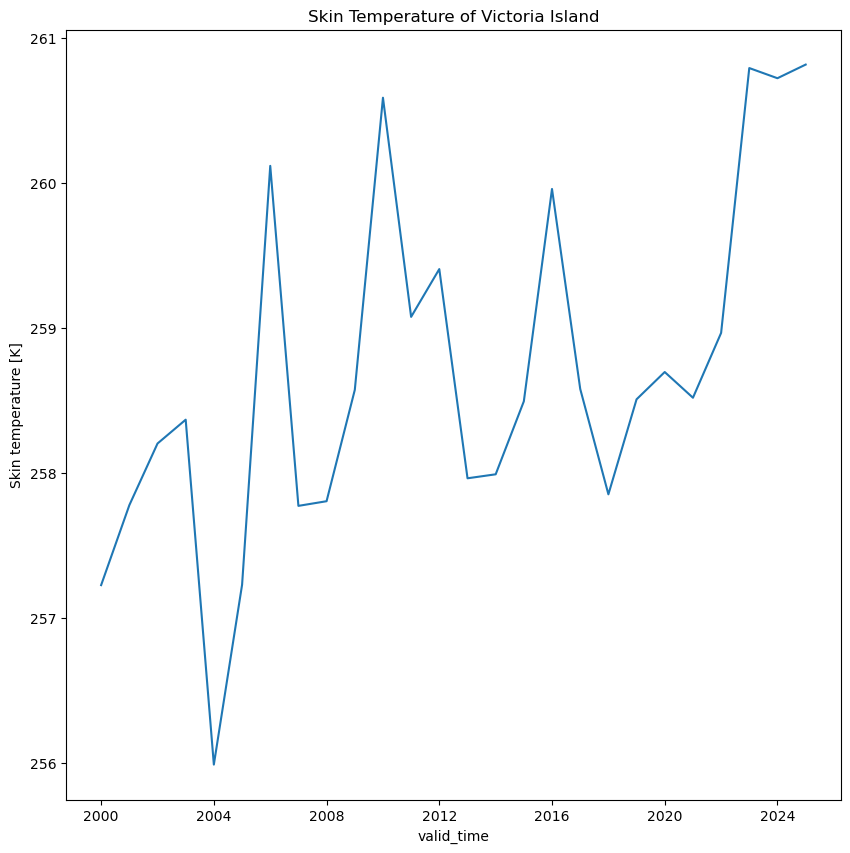

In [ ]:
fig = plt.figure(figsize=(10,10))                   
ax = plt.axes()  
skt_seasonal_to_2025.plot(ax=ax) 
ax.set_title('Skin Temperature of Victoria Island (2000 - 2025)')

# Plotting a scatter graph of skin temperature against time

Text(0.5, 1.0, 'Skin Temperature of Victoria Island (2000 - 2025)')

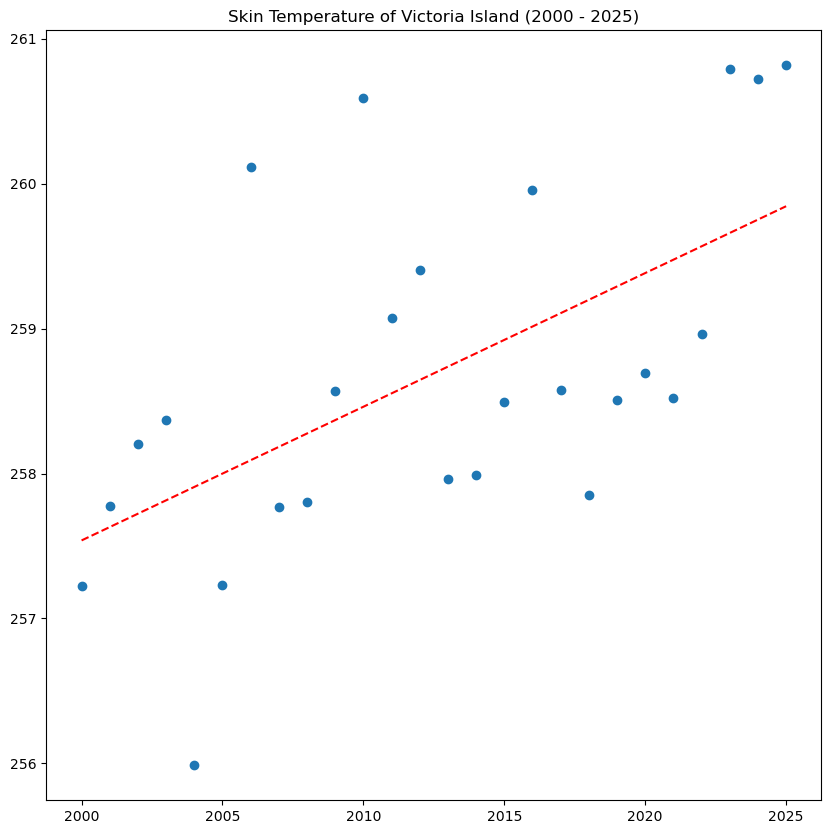

In [36]:
time_2 = np.arange(2000, 2026, 1)       # The time array needs to be set up again here, as you cannot create a regression line if the data types are different (valid_time has a special time data type, <M8[ns])

coef = np.polyfit(time_2, skt_seasonal_to_2025, 1)          # Caclulates the necessary coefficients for the regression line fit
fn = np.poly1d(coef)                                        # Creates the linear regression line function using these coefficients

fig = plt.figure(figsize=(10,10)) 
plt.plot(time_2, skt_seasonal_to_2025, 'o', time_2, fn(time_2), '--r')
plt.title('Skin Temperature of Victoria Island (2000 - 2025)')

